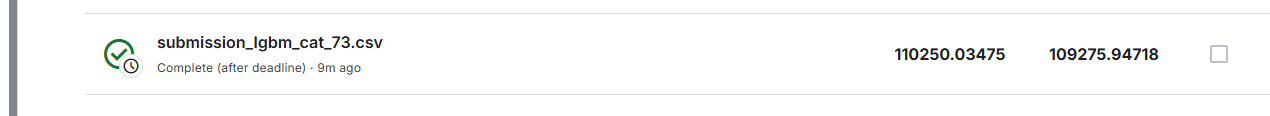

In [37]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 51.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 46.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lightgbm]2/3 [lightgbm]


In [38]:
import xgboost
import lightgbm

print("xgboost 설치 확인 완료")
print("lightgbm 설치 확인 완료")

xgboost 설치 확인 완료
lightgbm 설치 확인 완료


In [39]:
# ================================
# 1. 기본 설정 + 라이브러리 로드
# ================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingRegressor

import xgboost as xgb
import lightgbm as lgb

# 랜덤 고정 (재현성)
SEED = 42
np.random.seed(SEED)

print("1번 셀 실행 완료")

1번 셀 실행 완료


### 라이브러리 불러옴

In [40]:
# ================================
# 2. 데이터 경로 설정 (수정 버전)
# ================================

BASE_PATH = "/home/jovyan/data/data"  # ← 찾은 경로로 바꿔라

TRAIN_PATH = os.path.join(BASE_PATH, "train.csv")
TEST_PATH = os.path.join(BASE_PATH, "test.csv")
SUB_PATH = os.path.join(BASE_PATH, "sample_submission.csv")

print("train 존재:", os.path.exists(TRAIN_PATH))
print("test 존재:", os.path.exists(TEST_PATH))
print("sample_submission 존재:", os.path.exists(SUB_PATH))

train 존재: True
test 존재: True
sample_submission 존재: True


In [41]:
# ================================
# 3. 데이터 불러오기
# ================================

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUB_PATH)

print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample_submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

train shape: (15035, 21)
test shape: (6468, 20)
sample_submission shape: (6468, 2)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,15035,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
1,15036,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
2,15037,20140512T000000,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
3,15038,20150415T000000,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
4,15039,20150312T000000,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


### 학습 데이터, 테스트 데이터, 제출 샘플 파일
### train shape는 보통 (행 수, 열 수) 형태로 출력
### test shape는 train보다 열이 1개 적은 경우가 많습니다. 이유는 train에는 정답 컬럼이 있고, test에는 없기 때문입니다.
### train에 price 컬럼이 있고, train에 price 컬럼이 없고, sample_submission에는 sample_submission에는 2개 컬럼만

In [42]:
# ================================
# 4. 데이터 구조 확인
# ================================

print("train columns:")
print(train.columns.tolist())
print()

print("test columns:")
print(test.columns.tolist())
print()

print("train info")
print(train.info())
print()

print("test info")
print(test.info())
print()

train_missing = train.isnull().sum().sort_values(ascending=False)
test_missing = test.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "train_missing": train_missing,
    "test_missing": test_missing
}).fillna(0).astype(int)

display(missing_df[missing_df.sum(axis=1) > 0])

train columns:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

test columns:
['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

train info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15035 non-null  int64  
 1   date           15035 non-null  object 
 2   price          15035 non-null  float64
 3   bedrooms       15035 non-null  int64  
 4   bathrooms      15035 non-null  float64
 5   sqft_living    15035 non-null  int64  
 6   sqft_lot 

,train_missing,test_missing


### 어떤 컬럼들이 있는지, 숫자형인지 문자형인지, 결측치가 있는지 확인

In [43]:
# ================================
# 5. 타깃(price) 분리
# ================================

target_col = "price"

X = train.drop(columns=[target_col]).copy()
y = train[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (15035, 20)
y shape: (15035,)


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


0    221900.0
1    180000.0
2    510000.0
3    257500.0
4    291850.0
Name: price, dtype: float64

### 입력 데이터 X를 보고 정답 y를 맞추도록 학습

In [44]:
# ================================
# 6. Train / Validation 분리
# ================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (12028, 20)
X_valid: (3007, 20)
y_train: (12028,)
y_valid: (3007,)


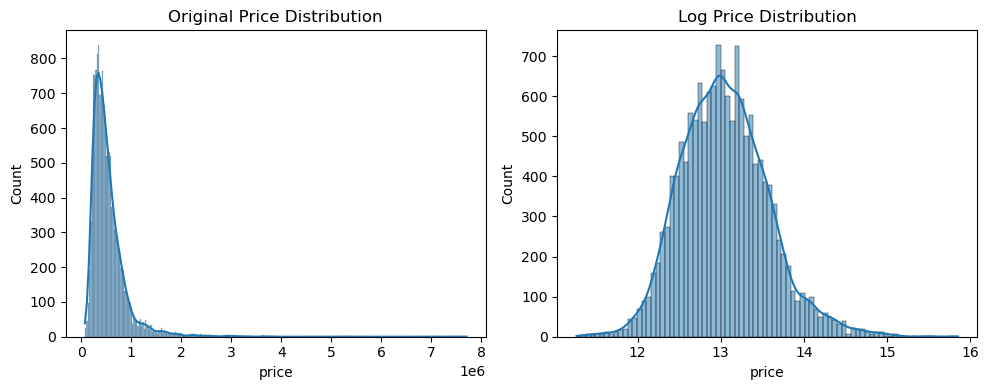

In [45]:
# ================================
# 7. 타깃(price) 분포 확인
# ================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True)
plt.title("Original Price Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(y), kde=True)
plt.title("Log Price Distribution")

plt.tight_layout()
plt.show()

### 왼쪽 그래프: 가격이 오른쪽으로 길게 늘어져 있으면 (skewed), 데이터가 한쪽으로 치우친 상태

### 오른쪽 그래프: 로그 변환 후 분포가 더 대칭에 가까워지면 모델 학습이 훨씬 안정적으로 진행됩니다

In [46]:
# ================================
# 8. 로그 변환 적용
# ================================

y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

print("로그 변환 완료")

로그 변환 완료


### 타깃 변수(price)에 로그 변환을 적용 :  큰 값의 영향 감소, 분포를 정규에 가깝게 만듦, 모델 안정성 증가

In [47]:
# ================================
# 9. 피처 엔지니어링
# ================================

def feature_engineering(df):
    df = df.copy()
    
    # date를 문자열로 바꾼 뒤 연/월/일 분리
    if "date" in df.columns:
        df["date"] = df["date"].astype(str)
        df["sale_year"] = df["date"].str[:4].astype(int)
        df["sale_month"] = df["date"].str[4:6].astype(int)
        df["sale_day"] = df["date"].str[6:8].astype(int)
    
    # 리모델링 여부
    if "yr_renovated" in df.columns:
        df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)
    
    # 집 나이
    if "yr_built" in df.columns and "sale_year" in df.columns:
        df["house_age"] = df["sale_year"] - df["yr_built"]
    
    # 리모델링 후 경과 연수
    if "yr_renovated" in df.columns and "sale_year" in df.columns:
        renovated_year = df["yr_renovated"].replace(0, np.nan)
        df["years_since_renovation"] = df["sale_year"] - renovated_year
        df["years_since_renovation"] = df["years_since_renovation"].fillna(-1)
    
    # 면적 비율
    if "sqft_living" in df.columns and "sqft_lot" in df.columns:
        df["living_lot_ratio"] = df["sqft_living"] / (df["sqft_lot"] + 1)
    
    # 지상+지하 총면적 확인용
    if "sqft_above" in df.columns and "sqft_basement" in df.columns:
        df["total_floor_area"] = df["sqft_above"] + df["sqft_basement"]
    
    # 방/욕실 비율
    if "bedrooms" in df.columns and "bathrooms" in df.columns:
        df["bed_bath_ratio"] = df["bedrooms"] / (df["bathrooms"] + 1)
    
    # 침실당 생활면적
    if "sqft_living" in df.columns and "bedrooms" in df.columns:
        df["living_per_bedroom"] = df["sqft_living"] / (df["bedrooms"] + 1)
    
    return df

### 원본 데이터만 그대로 쓰는 것보다, 의미 있는 새 변수를 만들어 주면 모델 성능이 더 좋아질 수 있다

In [48]:
# ================================
# 10. 피처 엔지니어링 적용
# ================================

X_train_fe = feature_engineering(X_train)
X_valid_fe = feature_engineering(X_valid)
test_fe = feature_engineering(test)

print("원래 X_train shape:", X_train.shape)
print("FE 적용 후 X_train shape:", X_train_fe.shape)

display(X_train_fe.head())

원래 X_train shape: (12028, 20)
FE 적용 후 X_train shape: (12028, 30)


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sale_year,sale_month,sale_day,is_renovated,house_age,years_since_renovation,living_lot_ratio,total_floor_area,bed_bath_ratio,living_per_bedroom
1068,1068,20140711T000000,2,1.00,1030,8786,1.0,0,0,3,...,2014,7,11,0,58,-1.0,0.117219,1030,1.000000,343.333333
14878,14878,20140528T000000,2,2.50,1050,1609,2.0,0,0,3,...,2014,5,28,0,9,-1.0,0.652174,1050,0.571429,350.000000
13314,13314,20141117T000000,4,1.75,2630,11213,1.0,0,2,4,...,2014,11,17,0,66,-1.0,0.234528,2630,1.454545,526.000000
2470,2470,20141204T000000,4,2.50,3000,10920,1.0,0,0,4,...,2014,12,4,0,45,-1.0,0.274700,3000,1.142857,600.000000
11619,11619,20140609T000000,4,1.75,2470,131790,2.0,0,2,3,...,2014,6,9,0,77,-1.0,0.018742,2470,1.454545,494.000000


### 학습 데이터와 검증 데이터, 테스트 데이터에 동일한 방식으로 피처 엔지니어링을 적용

In [49]:
# ================================
# 11. 추가된 컬럼 확인
# ================================

new_cols = [col for col in X_train_fe.columns if col not in X_train.columns]

print("새로 추가된 컬럼 수:", len(new_cols))
print("새로 추가된 컬럼 목록:")
print(new_cols)

새로 추가된 컬럼 수: 10
새로 추가된 컬럼 목록:
['sale_year', 'sale_month', 'sale_day', 'is_renovated', 'house_age', 'years_since_renovation', 'living_lot_ratio', 'total_floor_area', 'bed_bath_ratio', 'living_per_bedroom']


### 피처 엔지니어링으로 어떤 컬럼이 새로 생겼는지 확인

In [50]:
# ================================
# 12. 전처리 파이프라인
# ================================

# 숫자형 / 범주형 분리
numeric_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_fe.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("숫자형 컬럼 수:", len(numeric_cols))
print("범주형 컬럼 수:", len(categorical_cols))

# 숫자형 처리
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# 범주형 처리
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 합치기
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("전처리 파이프라인 생성 완료")

숫자형 컬럼 수: 29
범주형 컬럼 수: 1
전처리 파이프라인 생성 완료


### 머신러닝 모델은 문자나 결측치를 그대로 처리하지 못하는 경우가 많습니다. 그래서 숫자형과 범주형을 나눠 각각 다르게 처리

In [51]:
# ================================
# 13. 기본 모델 구성
# ================================

models = {
    "gbr": GradientBoostingRegressor(
        random_state=SEED
    ),
    
    "xgb": xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    ),
    
    "lgbm": lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("생성된 모델:", list(pipelines.keys()))

생성된 모델: ['gbr', 'xgb', 'lgbm']


### 처음에는 여러 모델을 비교하고, 그다음 가장 성능이 좋은 모델을 튜닝하는 방식이 효율적

In [52]:
# ================================
# 14. 평가 함수 정의
# ================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(model, X_tr, y_tr, X_va, y_va):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    score = rmse(y_va, pred)
    return score

### 예측값과 실제값의 차이를 측정하는 지표입니다. 값이 작을수록 성능이 좋다.

In [53]:
# ================================
# 15. 기본 모델 성능 비교
# ================================

baseline_scores = []

for name, pipe in pipelines.items():
    score = evaluate_model(
        pipe,
        X_train_fe, y_train_log,
        X_valid_fe, y_valid_log
    )
    baseline_scores.append((name, score))
    print(f"{name}: valid RMSE(log) = {score:.5f}")

baseline_df = pd.DataFrame(
    baseline_scores,
    columns=["model", "valid_rmse_log"]
).sort_values("valid_rmse_log")

display(baseline_df)

gbr: valid RMSE(log) = 0.18495
xgb: valid RMSE(log) = 0.16753
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4086
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 283
[LightGBM] [Info] Start training from score 13.047364
lgbm: valid RMSE(log) = 0.16295


,model,valid_rmse_log
2,lgbm,0.162949
1,xgb,0.167526
0,gbr,0.184948


### valid RMSE(log)` 값이 작을수록 좋다.

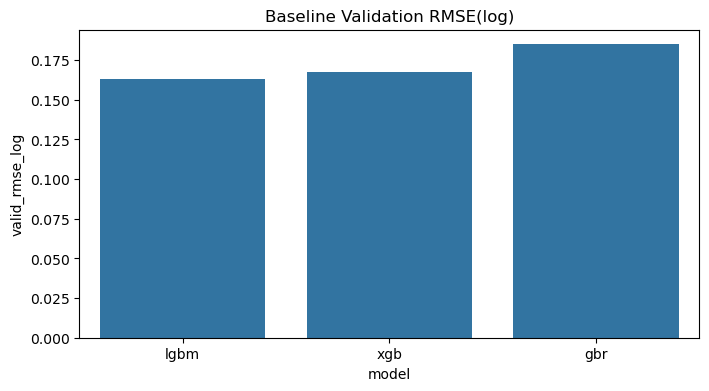

In [54]:
# ================================
# 16. 모델 성능 시각화
# ================================

plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_df, x="model", y="valid_rmse_log")
plt.title("Baseline Validation RMSE(log)")
plt.show()

### 막대가 낮을 수록 좋은 모델임

In [55]:
# ================================
# 17. 최고 모델 선택
# ================================

best_model_name = baseline_df.iloc[0]["model"]
print("현재 최고 모델:", best_model_name)

현재 최고 모델: lgbm


In [56]:
# ================================
# 18. LightGBM 하이퍼파라미터 튜닝
# ================================

lgbm_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgb.LGBMRegressor(random_state=SEED))
])

param_dist = {
    "model__n_estimators": [300, 500, 700, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.07],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 4, 6, 8, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_samples": [5, 10, 20, 30]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

lgbm_search.fit(X_train_fe, y_train_log)

print("best score:", -lgbm_search.best_score_)
print("best params:", lgbm_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3991
[LightGBM] [Info] Number of data points in the train set: 8018, number of used features: 253
[LightGBM] [Info] Start training from score 13.048368
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

### 튜닝 결과가 지금은 더 안 좋아졌다.

### 기본 lgbm valid RMSE(log): 0.162949
### 튜닝 search best score: 0.165195

### 즉, 현재 튜닝 조합은 채택하면 안 되고 지금은 기본 lgbm이 더 좋다.

In [57]:
# ================================
# 19. 기본 lgbm vs 튜닝 lgbm 비교
# ================================

base_lgbm = pipelines["lgbm"]
tuned_lgbm = lgbm_search.best_estimator_

base_lgbm.fit(X_train_fe, y_train_log)
base_pred = base_lgbm.predict(X_valid_fe)
base_score = rmse(y_valid_log, base_pred)

tuned_lgbm.fit(X_train_fe, y_train_log)
tuned_pred = tuned_lgbm.predict(X_valid_fe)
tuned_score = rmse(y_valid_log, tuned_pred)

print("기본 lgbm valid RMSE(log):", base_score)
print("튜닝 lgbm valid RMSE(log):", tuned_score)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4086
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 283
[LightGBM] [Info] Start training from score 13.047364
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4086
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 283
[LightGBM] [Info] Start training from score 13.047364
기본 lgbm valid RMSE(log): 0.16294858337442755
튜닝 lgbm valid RMSE(log): 0.16479499866967443


### 랜덤서치 = 무조건 좋아지는 게 아님, 파라미터 범위가 안 맞으면 오히려 성능 떨어짐 그래서 항상 직접 비교가 정답

In [58]:
# ================================
# 20. 최종 모델 선택
# ================================

final_model = pipelines["lgbm"]
final_model_name = "base_lgbm"

print("최종 선택 모델:", final_model_name)

최종 선택 모델: base_lgbm

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [59]:
# ================================
# 21. 전체 데이터로 재학습
# ================================

X_full_fe = feature_engineering(X)
y_full_log = np.log1p(y)
test_full_fe = feature_engineering(test)

final_model.fit(X_full_fe, y_full_log)

print("전체 데이터 재학습 완료")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4145
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 289
[LightGBM] [Info] Start training from score 13.048122
전체 데이터 재학습 완료


In [61]:
# ================================
# 22. 테스트 예측
# ================================

test_pred_log = final_model.predict(test_full_fe)
test_pred = np.expm1(test_pred_log)

print("예측 완료")
print(test_pred[:10])

예측 완료
[ 521794.92542028  472258.23724486 1446096.22729023  304838.18188662
  327742.35474516  312148.69554592  442808.20812831  695193.28862482
  285238.23988488  335306.90207922]


### 값이 전부 양수, 값 크기가 현실적인 집값 범위, 이상치 (0, 음수, 말도 안 되는 값) 없음

In [62]:
# ================================
# 23. 제출 파일 생성
# ================================

submission = sample_submission.copy()

target_candidates = [col for col in submission.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

submission[sub_target_col] = test_pred

display(submission.head())
print(submission.shape)

,id,price
0,15035,5.217949e+05
1,15036,4.722582e+05
2,15037,1.446096e+06
3,15038,3.048382e+05
4,15039,3.277424e+05


(6468, 2)


In [63]:
# ================================
# 24. 제출 파일 저장
# ================================

save_path = "submission_lgbm_base.csv"
submission.to_csv(save_path, index=False)

print("저장 완료:", save_path)

저장 완료: submission_lgbm_base.csv


In [64]:
# ================================
# 25. LGBM + XGB 앙상블
# ================================

final_lgbm = pipelines["lgbm"]
final_xgb = pipelines["xgb"]

X_full_fe = feature_engineering(X)
y_full_log = np.log1p(y)
test_full_fe = feature_engineering(test)

final_lgbm.fit(X_full_fe, y_full_log)
final_xgb.fit(X_full_fe, y_full_log)

lgbm_pred_log = final_lgbm.predict(test_full_fe)
xgb_pred_log = final_xgb.predict(test_full_fe)

ensemble_pred_log = (lgbm_pred_log + xgb_pred_log) / 2
ensemble_pred = np.expm1(ensemble_pred_log)

print("앙상블 예측 완료")
print(ensemble_pred[:10])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4145
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 289
[LightGBM] [Info] Start training from score 13.048122
앙상블 예측 완료
[ 540134.4131958   444503.18580623 1414257.21372144  302958.69669161
  324283.09099664  310124.20234134  440354.58500855  686286.1058037
  281286.44682413  340650.50388223]


In [65]:
# ================================
# 26. 앙상블 제출 파일 생성
# ================================

submission_ens = sample_submission.copy()

target_candidates = [col for col in submission_ens.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

submission_ens[sub_target_col] = ensemble_pred

display(submission_ens.head())
print(submission_ens.shape)

,id,price
0,15035,5.401344e+05
1,15036,4.445032e+05
2,15037,1.414257e+06
3,15038,3.029587e+05
4,15039,3.242831e+05


(6468, 2)


In [66]:
# ================================
# 27. 앙상블 제출 파일 저장
# ================================

save_path_ens = "submission_lgbm_xgb_ensemble.csv"
submission_ens.to_csv(save_path_ens, index=False)

print("저장 완료:", save_path_ens)

저장 완료: submission_lgbm_xgb_ensemble.csv


In [68]:
!pip install catboost -q

In [70]:
# ================================
# 28. CatBoost 모델 준비
# ================================

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=SEED,
    verbose=0
)

print("CatBoost 준비 완료")

CatBoost 준비 완료


In [71]:
# ================================
# 29. CatBoost용 데이터 준비
# ================================

X_full_fe = feature_engineering(X)
test_full_fe = feature_engineering(test)
y_full_log = np.log1p(y)

cat_features = X_full_fe.select_dtypes(exclude=["int64", "float64"]).columns.tolist()
cat_feature_indices = [X_full_fe.columns.get_loc(col) for col in cat_features]

print("범주형 컬럼:", cat_features)
print("범주형 인덱스:", cat_feature_indices)
print("X_full_fe shape:", X_full_fe.shape)
print("test_full_fe shape:", test_full_fe.shape)

범주형 컬럼: ['date']
범주형 인덱스: [1]
X_full_fe shape: (15035, 30)
test_full_fe shape: (6468, 30)


In [72]:
# ================================
# 30. CatBoost 학습 및 예측
# ================================

cat_model.fit(
    X_full_fe,
    y_full_log,
    cat_features=cat_feature_indices
)

cat_pred_log = cat_model.predict(test_full_fe)
cat_pred = np.expm1(cat_pred_log)

print("CatBoost 예측 완료")
print(cat_pred[:10])

CatBoost 예측 완료
[ 523768.28478174  433804.48649423 1411218.63319483  301150.73047168
  322382.00476262  309738.18302387  438332.72816393  654326.39830182
  278138.62626771  330085.30935738]


In [73]:
# ================================
# 31. CatBoost 제출 파일 생성
# ================================

submission_cat = sample_submission.copy()

target_candidates = [col for col in submission_cat.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

submission_cat[sub_target_col] = cat_pred

display(submission_cat.head())
print(submission_cat.shape)

save_path_cat = "submission_catboost.csv"
submission_cat.to_csv(save_path_cat, index=False)

print("저장 완료:", save_path_cat)

,id,price
0,15035,5.237683e+05
1,15036,4.338045e+05
2,15037,1.411219e+06
3,15038,3.011507e+05
4,15039,3.223820e+05


(6468, 2)
저장 완료: submission_catboost.csv


In [75]:
# ================================
# 32. LGBM + CatBoost 앙상블
# ================================

lgbm_model = pipelines["lgbm"]
lgbm_model.fit(X_full_fe, y_full_log)

lgbm_pred_log = lgbm_model.predict(test_full_fe)

ensemble_lgbm_cat_log = (lgbm_pred_log + cat_pred_log) / 2
ensemble_lgbm_cat = np.expm1(ensemble_lgbm_cat_log)

print("LGBM + CatBoost 앙상블 완료")
print(ensemble_lgbm_cat[:10])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4145
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 289
[LightGBM] [Info] Start training from score 13.048122
LGBM + CatBoost 앙상블 완료
[ 522780.67398964  452623.17982737 1428550.99368472  302988.84659676
  325051.13042484  310941.10342047  440564.78517198  674450.38460097
  281666.06512915  332685.8616217 ]


In [76]:
# ================================
# 33. LGBM + CatBoost 제출 파일 저장
# ================================

submission_lgbm_cat = sample_submission.copy()

target_candidates = [col for col in submission_lgbm_cat.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

submission_lgbm_cat[sub_target_col] = ensemble_lgbm_cat

display(submission_lgbm_cat.head())
print(submission_lgbm_cat.shape)

save_path_lgbm_cat = "submission_lgbm_catboost_ensemble.csv"
submission_lgbm_cat.to_csv(save_path_lgbm_cat, index=False)

print("저장 완료:", save_path_lgbm_cat)

,id,price
0,15035,5.227807e+05
1,15036,4.526232e+05
2,15037,1.428551e+06
3,15038,3.029888e+05
4,15039,3.250511e+05


(6468, 2)
저장 완료: submission_lgbm_catboost_ensemble.csv


In [77]:
# ================================
# 34. 가중 앙상블 후보 만들기
# ================================

# 전제:
# lgbm_pred_log  -> LGBM 로그 예측값
# cat_pred_log   -> CatBoost 로그 예측값

blend_73_log = 0.7 * lgbm_pred_log + 0.3 * cat_pred_log
blend_82_log = 0.8 * lgbm_pred_log + 0.2 * cat_pred_log
blend_91_log = 0.9 * lgbm_pred_log + 0.1 * cat_pred_log

blend_73 = np.expm1(blend_73_log)
blend_82 = np.expm1(blend_82_log)
blend_91 = np.expm1(blend_91_log)

print("가중 앙상블 생성 완료")
print("73 샘플:", blend_73[:5])
print("82 샘플:", blend_82[:5])
print("91 샘플:", blend_91[:5])

가중 앙상블 생성 완료
73 샘플: [ 522386.15129195  460377.28956126 1435543.39665735  303727.23058752
  326124.95810186]
82 샘플: [ 522189.00160617  464304.0177878  1439052.42246303  304097.09709767
  326663.20150224]
91 샘플: [ 521991.92632498  468264.23845939 1442570.02568515  304467.41401455
  327202.33322797]


In [78]:
# ================================
# 35. 7:3 제출 파일 저장
# ================================

sub_73 = sample_submission.copy()

target_candidates = [col for col in sub_73.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

sub_73[sub_target_col] = blend_73
sub_73.to_csv("submission_lgbm_cat_73.csv", index=False)

print("저장 완료: submission_lgbm_cat_73.csv")
display(sub_73.head())

저장 완료: submission_lgbm_cat_73.csv


,id,price
0,15035,5.223862e+05
1,15036,4.603773e+05
2,15037,1.435543e+06
3,15038,3.037272e+05
4,15039,3.261250e+05


In [79]:
# ================================
# 36. 8:2 제출 파일 저장
# ================================

sub_82 = sample_submission.copy()

target_candidates = [col for col in sub_82.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

sub_82[sub_target_col] = blend_82
sub_82.to_csv("submission_lgbm_cat_82.csv", index=False)

print("저장 완료: submission_lgbm_cat_82.csv")
display(sub_82.head())

저장 완료: submission_lgbm_cat_82.csv


,id,price
0,15035,5.221890e+05
1,15036,4.643040e+05
2,15037,1.439052e+06
3,15038,3.040971e+05
4,15039,3.266632e+05


In [80]:
# ================================
# 37. 9:1 제출 파일 저장
# ================================

sub_91 = sample_submission.copy()

target_candidates = [col for col in sub_91.columns if col.lower() != "id"]
if len(target_candidates) == 1:
    sub_target_col = target_candidates[0]
else:
    sub_target_col = "price"

sub_91[sub_target_col] = blend_91
sub_91.to_csv("submission_lgbm_cat_91.csv", index=False)

print("저장 완료: submission_lgbm_cat_91.csv")
display(sub_91.head())

저장 완료: submission_lgbm_cat_91.csv


,id,price
0,15035,5.219919e+05
1,15036,4.682642e+05
2,15037,1.442570e+06
3,15038,3.044674e+05
4,15039,3.272023e+05


In [81]:
# ================================
# 38. 추가 가중 앙상블 후보
# ================================

blend_75_log = 0.75 * lgbm_pred_log + 0.25 * cat_pred_log
blend_80_log = 0.80 * lgbm_pred_log + 0.20 * cat_pred_log
blend_85_log = 0.85 * lgbm_pred_log + 0.15 * cat_pred_log
blend_95_log = 0.95 * lgbm_pred_log + 0.05 * cat_pred_log

blend_75 = np.expm1(blend_75_log)
blend_80 = np.expm1(blend_80_log)
blend_85 = np.expm1(blend_85_log)
blend_95 = np.expm1(blend_95_log)

print("추가 가중 앙상블 생성 완료")
print(blend_75[:3], blend_80[:3], blend_85[:3], blend_95[:3])

추가 가중 앙상블 생성 완료
[ 522287.56714673  462336.48487859 1437296.83869155] [ 522189.00160617  464304.0177878  1439052.42246303] [ 522090.45466675  466279.92377053 1440810.15058783] [ 521893.41657732  470256.99763865 1444332.05037741]


In [82]:
# ================================
# 39. 제출 파일 저장 함수
# ================================

def save_submission(pred, filename):
    sub = sample_submission.copy()
    target_candidates = [col for col in sub.columns if col.lower() != "id"]
    if len(target_candidates) == 1:
        sub_target_col = target_candidates[0]
    else:
        sub_target_col = "price"
    sub[sub_target_col] = pred
    sub.to_csv(filename, index=False)
    print("저장 완료:", filename)
    return sub.head()

In [83]:
save_submission(blend_75, "submission_lgbm_cat_75.csv")
save_submission(blend_80, "submission_lgbm_cat_80.csv")
save_submission(blend_85, "submission_lgbm_cat_85.csv")
save_submission(blend_95, "submission_lgbm_cat_95.csv")

저장 완료: submission_lgbm_cat_75.csv
저장 완료: submission_lgbm_cat_80.csv
저장 완료: submission_lgbm_cat_85.csv
저장 완료: submission_lgbm_cat_95.csv


,id,price
0,15035,5.218934e+05
1,15036,4.702570e+05
2,15037,1.444332e+06
3,15038,3.046527e+05
4,15039,3.274722e+05
